# Tarea 7: Clasificación de Texto con Naive Bayes
## Análisis de Sentimiento en Reseñas de Películas

**Nombre:** John David Ortega Echeverría

**Fecha:** 19/06/2026

### Objetivo:
Familiarizar al estudiante con el algoritmo Naive Bayes para clasificación de texto, aplicando técnicas de preprocesamiento como Bag of Words (CountVectorizer) y TF-IDF, analizando el efecto de hiperparámetros como `alpha` (suavizado Laplaciano) y n-gramas, y evaluando el modelo mediante métricas de precisión, recall y F1-score.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.
6. NO ELIMINAR NINGÚN COMENTARIO

### Descripción del Dataset:
Utilizaremos el dataset **Rotten Tomatoes Movie Reviews** que contiene reseñas de críticos de cine. Cada reseña está clasificada como:
- **fresh**: Reseña positiva
- **rotten**: Reseña negativa

### Archivo requerido:
- `critics.csv` - Dataset de reseñas de películas

## Parte 1: Configuración y Carga de Datos

In [70]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [71]:
# TODO: Cargar el dataset critics.csv
#
# Instrucciones:
# 1. Use pd.read_csv('critics.csv') para cargar el dataset
# 2. Imprima las dimensiones con .shape
# 3. Imprima los nombres de columnas
# 4. Muestre las primeras filas con .head()
critics = pd.read_csv("critics.csv")

print("Dimensiones originales:", critics.shape)
print("\nColumnas:")
print(list(critics.columns))

print("\nPrimeras filas:")
display(critics.head())



Dimensiones originales: (27631, 8)

Columnas:
['critic', 'fresh', 'imdb', 'publication', 'quote', 'review_date', 'rtid', 'title']

Primeras filas:


,critic,fresh,imdb,publication,quote,review_date,rtid,title
0,Owen Gleiberman,fresh,114709,Entertainment Weekly,NaN,2011-09-07,9559,Toy story
1,Derek Adams,fresh,114709,Time Out,"So ingenious in concept, design and execution ...",2009-10-04,9559,Toy story
2,Richard Corliss,fresh,114709,TIME Magazine,The year's most inventive comedy.,2008-08-31,9559,Toy story
3,David Ansen,fresh,114709,Newsweek,A winning animated feature that has something ...,2008-08-18,9559,Toy story
4,Leonard Klady,fresh,114709,Variety,The film sports a provocative and appealing st...,2008-06-09,9559,Toy story


In [72]:
# TODO: Limpiar el dataset
#
# Instrucciones:
# 1. Elimine filas con quotes nulos: critics = critics[~critics.quote.isnull()]
# 2. Filtre solo fresh y rotten: critics = critics[critics['fresh'].isin(['fresh', 'rotten'])]
# 3. Imprima las dimensiones después de limpiar

critics = critics[~critics.quote.isnull()]
critics = critics[critics["fresh"].isin(["fresh", "rotten"])]

print("Dimensiones después de limpiar:", critics.shape)

Dimensiones después de limpiar: (15534, 8)


### Pregunta 1: Tamaño del Dataset
¿Cuántas reseñas válidas quedan después de limpiar el dataset?

A) Aproximadamente 5,000  
B) Aproximadamente 10,000  
C) Aproximadamente 15,000  
D) Aproximadamente 20,000  

**Su Respuesta:** D

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [73]:
# TODO: Explorar estadísticas básicas
#
# Instrucciones:
# 1. Calcule n_reviews = len(critics)
# 2. Calcule n_movies = critics.rtid.nunique()
# 3. Calcule n_critics = critics.critic.nunique()
# 4. Imprima las estadísticas
n_reviews = len(critics)
n_movies = critics.rtid.nunique()
n_critics = critics.critic.nunique()

print(f"Número de reseñas: {n_reviews}")
print(f"Número de películas: {n_movies}")
print(f"Número de críticos: {n_critics}")



Número de reseñas: 15534
Número de películas: 1921
Número de críticos: 621


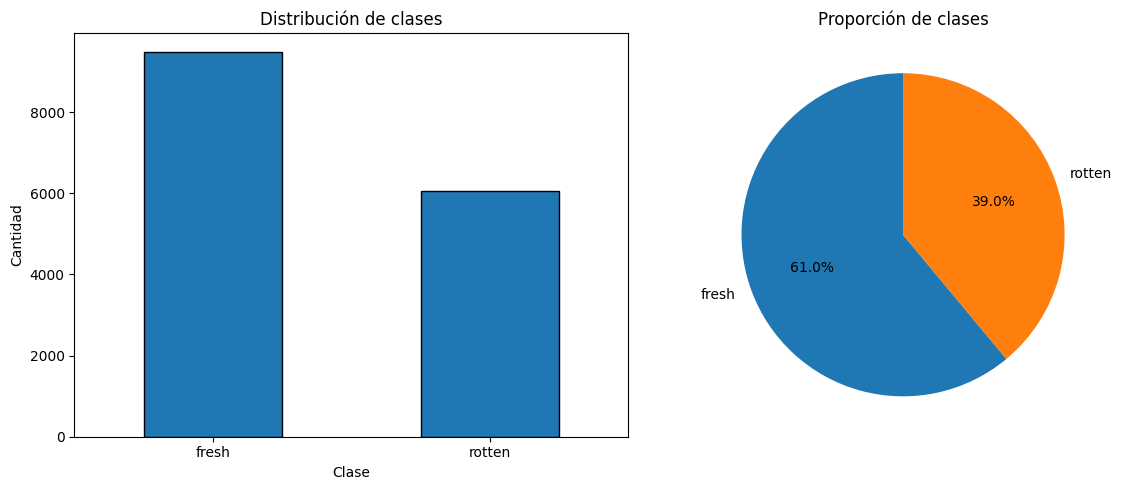

Conteo de clases:
fresh
fresh     9482
rotten    6052
Name: count, dtype: int64


In [74]:
# TODO: Visualizar distribución de clases
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, use critics['fresh'].value_counts().plot(kind='bar')
# 3. En el segundo subplot, use .plot(kind='pie', autopct='%1.1f%%')
# 4. Agregue títulos y etiquetas
# 5. Imprima el conteo de clases

distribucion = critics["fresh"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
distribucion.plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("Distribución de clases")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=0)

# Gráfico circular
distribucion.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proporción de clases")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("Conteo de clases:")
print(distribucion)

### Pregunta 2: Balance de Clases
¿Cuál es la clase mayoritaria en el dataset?

A) rotten (negativas)  
B) fresh (positivas)  
C) Están perfectamente balanceadas  
D) No se puede determinar  

**Su Respuesta:** B

Estadísticas descriptivas:


,quote_length,word_count
count,15534.000000,15534.000000
mean,117.014484,19.447534
std,57.581577,9.792644
min,4.000000,1.000000
25%,72.000000,12.000000
50%,114.000000,19.000000
75%,158.000000,26.000000
max,256.000000,49.000000


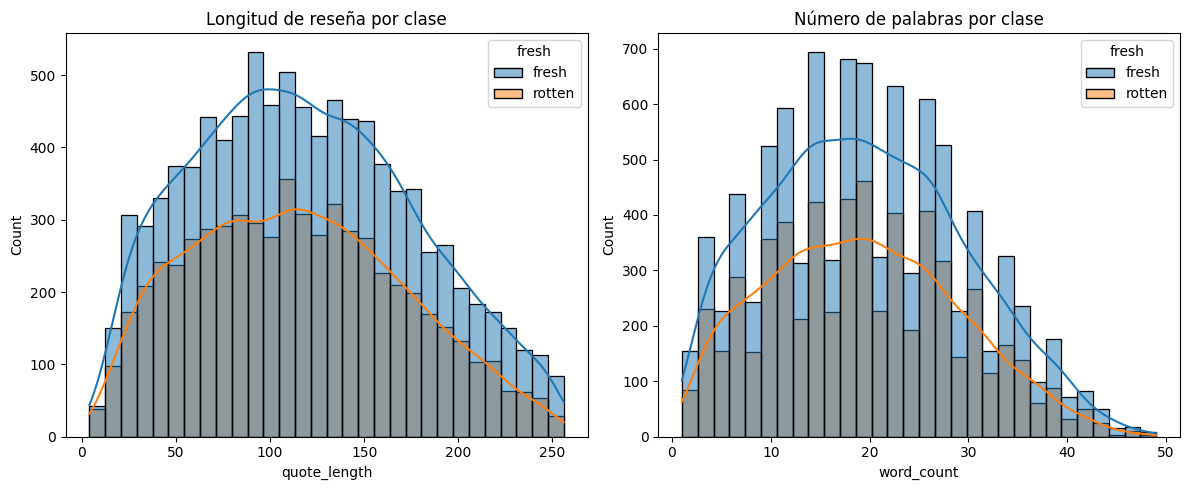

In [75]:
# TODO: Analizar longitud de las reseñas
#
# Instrucciones:
# 1. Cree una columna 'quote_length' con la longitud de cada quote: critics['quote'].apply(len)
# 2. Cree una columna 'word_count' con el número de palabras: critics['quote'].apply(lambda x: len(str(x).split()))
# 3. Imprima estadísticas descriptivas de estas columnas
# 4. Opcional: Cree histogramas comparando fresh vs rotten

critics["quote_length"] = critics["quote"].apply(len)
critics["word_count"] = critics["quote"].apply(lambda x: len(str(x).split()))

print("Estadísticas descriptivas:")
display(critics[["quote_length", "word_count"]].describe())

# Histogramas sencillos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=critics, x="quote_length", hue="fresh", bins=30, ax=axes[0], kde=True)
axes[0].set_title("Longitud de reseña por clase")

sns.histplot(data=critics, x="word_count", hue="fresh", bins=30, ax=axes[1], kde=True)
axes[1].set_title("Número de palabras por clase")

plt.tight_layout()
plt.show()

In [76]:
# TODO: Mostrar ejemplos de reseñas
#
# Instrucciones:
# 1. Imprima 3 ejemplos de reseñas 'fresh' usando critics[critics['fresh']=='fresh']['quote'].head(3)
# 2. Imprima 3 ejemplos de reseñas 'rotten'

print("Ejemplos fresh:")
for i, review in enumerate(critics[critics["fresh"] == "fresh"]["quote"].head(3), start=1):
    print(f"{i}. {review}")

print("\nEjemplos rotten:")
for i, review in enumerate(critics[critics["fresh"] == "rotten"]["quote"].head(3), start=1):
    print(f"{i}. {review}")


Ejemplos fresh:
1. So ingenious in concept, design and execution that you could watch it on a postage stamp-sized screen and still be engulfed by its charm.
2. The year's most inventive comedy.
3. A winning animated feature that has something for everyone on the age spectrum.

Ejemplos rotten:
1. A gloomy special-effects extravaganza filled with grotesque images, generating fear and despair.
2. Mediocre, regrettably.
3. The movie is too pat and practiced to really be convincing, and the progress of Ariel's relationships with the two grumps seems dictated mostly by the needs of the screenplay.


## Parte 3: Preprocesamiento de Texto - Bag of Words

### Teoría:
El modelo **Bag of Words (BoW)** representa el texto como un vector de frecuencias de palabras, ignorando el orden. **CountVectorizer** de Scikit-Learn implementa este enfoque.

$$\text{Vector} = [\text{count}(w_1), \text{count}(w_2), ..., \text{count}(w_n)]$$

In [77]:
# TODO: Crear una función para preparar los datos
#
# Instrucciones:
# 1. Defina la función make_xy(data, vectorizer) que:
#    a. Aplique vectorizer.fit_transform(data['quote']) para obtener X
#    b. Convierta 'fresh' a binario: y = (data['fresh'] == 'fresh').astype(int).values
#    c. Retorne X, y

def make_xy(data, vectorizer):
    """Prepara los datos para el modelo."""
    # X es la matriz de características creada desde el texto
    X = vectorizer.fit_transform(data["quote"])

    # y vale 1 si la reseña es fresh y 0 si es rotten
    y = (data["fresh"] == "fresh").astype(int).values

    return X, y
    pass


In [78]:
# TODO: Aplicar CountVectorizer
#
# Instrucciones:
# 1. Cree vectorizer = CountVectorizer(min_df=5)
# 2. Use make_xy() para obtener X, y
# 3. Imprima la forma de X y y
# 4. Imprima algunos ejemplos de palabras del vocabulario con vectorizer.get_feature_names_out()[:20]

vectorizer = CountVectorizer(min_df=5)

X, y = make_xy(critics, vectorizer)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("\nPrimeras 20 palabras del vocabulario:")
print(vectorizer.get_feature_names_out()[:20])



Forma de X: (15534, 6166)
Forma de y: (15534,)

Primeras 20 palabras del vocabulario:
['000' '007' '10' '100' '11' '12' '13' '13th' '15' '16' '17' '1930s'
 '1933' '1939' '1940s' '1950s' '1956' '1960s' '1961' '1963']


### Pregunta 3: Dimensiones del Vocabulario
¿Aproximadamente cuántas características (palabras únicas) tiene el vocabulario con min_df=5?

A) 500-1,000  
B) 1,000-5,000  
C) 5,000-10,000  
D) 10,000-20,000  

**Su Respuesta:** D

In [79]:
# TODO: Dividir en train y test
#
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.3, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto
# 4. Imprima la distribución de clases en entrenamiento

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=22,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribución de clases en entrenamiento:")
print(pd.Series(y_train).value_counts(normalize=True))

X_train: (10873, 6166)
X_test: (4661, 6166)
y_train: (10873,)
y_test: (4661,)

Distribución de clases en entrenamiento:
1    0.610411
0    0.389589
Name: proportion, dtype: float64


## Parte 4: Naive Bayes Multinomial

### Teoría - Teorema de Bayes:
$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

**Naive Bayes** asume independencia condicional entre características:
$$P(X|C) = P(x_1|C) \cdot P(x_2|C) \cdot ... \cdot P(x_n|C)$$

**Multinomial Naive Bayes** es apropiado para conteos de palabras.

In [80]:
# TODO: Entrenar Multinomial Naive Bayes
#
# Instrucciones:
# 1. Cree el modelo: clf_nb = MultinomialNB()
# 2. Entrene con clf_nb.fit(X_train, y_train)
# 3. Prediga en train y test
# 4. Calcule y muestre las precisiones en train y test con accuracy_score()

clf_nb = MultinomialNB()
clf_nb.fit(X_train, y_train)

y_pred_train = clf_nb.predict(X_train)
y_pred_test = clf_nb.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Accuracy en entrenamiento:", round(train_acc, 4))
print("Accuracy en prueba:", round(test_acc, 4))

Accuracy en entrenamiento: 0.8642
Accuracy en prueba: 0.7702


### Pregunta 4: Precisión del Modelo Base
¿Cuál es la precisión aproximada del modelo Naive Bayes en el conjunto de prueba?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** C

## Parte 5: Matriz de Confusión y Métricas

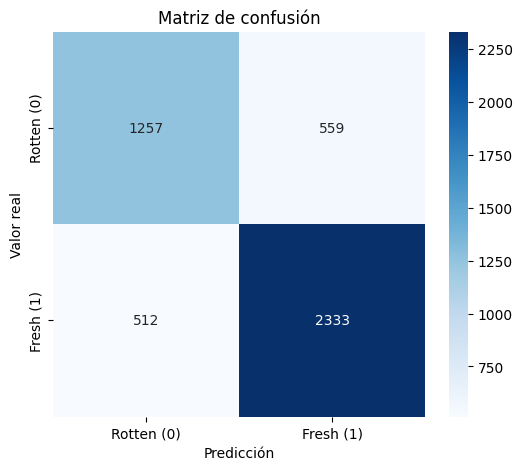

TN: 1257
FP: 559
FN: 512
TP: 2333


In [81]:
# TODO: Calcular y visualizar la matriz de confusión
#
# Instrucciones:
# 1. Calcule cm = confusion_matrix(y_test, y_pred_test)
# 2. Visualice con sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# 3. Configure xticklabels y yticklabels como ['Rotten (0)', 'Fresh (1)']
# 4. Imprima TN, FP, FN, TP

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rotten (0)", "Fresh (1)"],
    yticklabels=["Rotten (0)", "Fresh (1)"]
)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

In [82]:
# TODO: Calcular métricas detalladas
#
# Instrucciones:
# 1. Calcule precision = precision_score(y_test, y_pred_test)
# 2. Calcule recall = recall_score(y_test, y_pred_test)
# 3. Calcule f1 = f1_score(y_test, y_pred_test)
# 4. Imprima las métricas
# 5. Use classification_report() para el reporte completo

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print("Precisión:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

print("\nReporte completo:")
print(classification_report(y_test, y_pred_test, target_names=["rotten", "fresh"]))

Precisión: 0.8067
Recall: 0.82
F1-score: 0.8133

Reporte completo:
              precision    recall  f1-score   support

      rotten       0.71      0.69      0.70      1816
       fresh       0.81      0.82      0.81      2845

    accuracy                           0.77      4661
   macro avg       0.76      0.76      0.76      4661
weighted avg       0.77      0.77      0.77      4661



### Pregunta 5: Interpretación de Métricas
Si el modelo tiene alto recall pero baja precisión para la clase 'Fresh', ¿qué significa?

A) El modelo detecta bien las reseñas positivas pero también clasifica muchas negativas como positivas  
B) El modelo no detecta las reseñas positivas  
C) El modelo es perfecto  
D) El modelo solo predice negativas  

**Su Respuesta:** A

## Parte 6: Efecto del Parámetro Alpha (Suavizado Laplaciano)

### Teoría:
El parámetro `alpha` es el **suavizado de Laplace** (additive smoothing). Evita probabilidades de cero para palabras no vistas:

$$P(w|C) = \frac{\text{count}(w,C) + \alpha}{\text{count}(C) + \alpha \cdot |V|}$$

- alpha=1.0: Suavizado estándar (default)
- alpha<1.0: Menos suavizado
- alpha>1.0: Más suavizado

In [83]:
# TODO: Experimentar con diferentes valores de alpha
#
# Instrucciones:
# 1. Defina alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
# 2. Para cada alpha:
#    a. Cree MultinomialNB(alpha=alpha)
#    b. Entrene y calcule precisiones train/test
#    c. Calcule precision y recall
# 3. Guarde resultados en un DataFrame e imprima

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

resultados_alpha = []

for alpha in alphas:
    modelo_alpha = MultinomialNB(alpha=alpha)
    modelo_alpha.fit(X_train, y_train)

    pred_train = modelo_alpha.predict(X_train)
    pred_test = modelo_alpha.predict(X_test)

    resultados_alpha.append({
        "alpha": alpha,
        "train_acc": accuracy_score(y_train, pred_train),
        "test_acc": accuracy_score(y_test, pred_test),
        "precision": precision_score(y_test, pred_test),
        "recall": recall_score(y_test, pred_test),
        "f1": f1_score(y_test, pred_test)
    })

alpha_df = pd.DataFrame(resultados_alpha)
display(alpha_df)

,alpha,train_acc,test_acc,precision,recall,f1
0,0.001,0.878047,0.748123,0.777667,0.822496,0.799453
1,0.010,0.877495,0.753915,0.783567,0.824605,0.803562
2,0.100,0.875471,0.761854,0.795772,0.820387,0.807892
3,0.500,0.869033,0.764857,0.802910,0.814763,0.808793
4,1.000,0.864159,0.770221,0.806708,0.820035,0.813317
5,2.000,0.855330,0.774083,0.800268,0.839367,0.819352
6,5.000,0.833257,0.758206,0.753542,0.897364,0.819188
7,10.000,0.764462,0.716155,0.693245,0.959578,0.804954


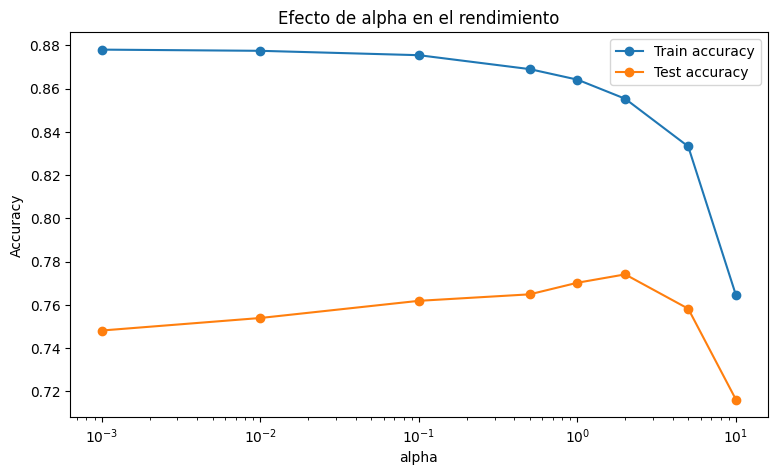

In [84]:
# TODO: Visualizar el efecto de alpha
#
# Instrucciones:
# 1. Grafique train_scores y test_scores vs alphas
# 2. Use plt.xscale('log') para escala logarítmica
# 3. Agregue leyenda, título y etiquetas

plt.figure(figsize=(9, 5))
plt.plot(alpha_df["alpha"], alpha_df["train_acc"], marker="o", label="Train accuracy")
plt.plot(alpha_df["alpha"], alpha_df["test_acc"], marker="o", label="Test accuracy")
plt.xscale("log")
plt.title("Efecto de alpha en el rendimiento")
plt.xlabel("alpha")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Pregunta 6: Efecto de Alpha
¿Qué ocurre cuando alpha es muy pequeño (ej: 0.001)?

A) El modelo generaliza mejor  
B) El modelo tiende a sobreajustar (train acc >> test acc)  
C) El modelo no aprende nada  
D) No hay efecto significativo  

**Su Respuesta:** B

## Parte 7: N-gramas

### Teoría:
Los **n-gramas** capturan secuencias de n palabras consecutivas:
- Unigrama (1-gram): palabras individuales
- Bigrama (2-gram): pares de palabras
- Trigrama (3-gram): tríos de palabras

Ejemplo: "I love this movie"
- Unigramas: ["I", "love", "this", "movie"]
- Bigramas: ["I love", "love this", "this movie"]

,ngram_range,n_features,test_acc,precision,recall,f1
0,"(1, 1)",6166,0.770221,0.806708,0.820035,0.813317
1,"(1, 2)",13054,0.769792,0.813517,0.808084,0.810792
2,"(2, 2)",6888,0.683330,0.723037,0.779965,0.750423
3,"(1, 3)",14727,0.762926,0.810271,0.798594,0.804390
4,"(2, 3)",8561,0.679682,0.725183,0.765202,0.744655


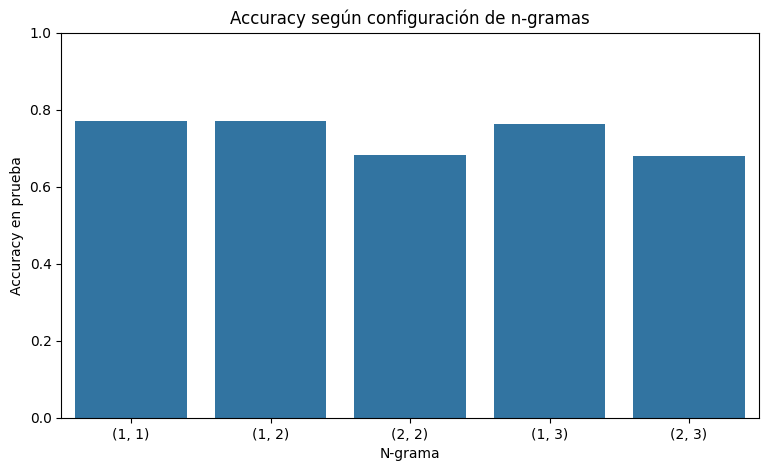

In [63]:
# TODO: Experimentar con diferentes n-gramas
#
# Instrucciones:
# 1. Defina ngram_configs = [(1,1), (1,2), (2,2), (1,3), (2,3)]
# 2. Para cada configuración:
#    a. Cree CountVectorizer(ngram_range=ngram, min_df=5)
#    b. Use make_xy() para crear X, y
#    c. Divida en train/test
#    d. Entrene MultinomialNB y calcule precisiones
# 3. Imprima los resultados comparativos

ngram_configs = [(1, 1), (1, 2), (2, 2), (1, 3), (2, 3)]

resultados_ngram = []

for ngram in ngram_configs:
    vect = CountVectorizer(ngram_range=ngram, min_df=5)
    X_ng, y_ng = make_xy(critics, vect)

    X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(
        X_ng, y_ng,
        test_size=0.3,
        random_state=22,
        stratify=y_ng
    )

    modelo_ng = MultinomialNB()
    modelo_ng.fit(X_train_ng, y_train_ng)

    pred_test_ng = modelo_ng.predict(X_test_ng)

    resultados_ngram.append({
        "ngram_range": str(ngram),
        "n_features": X_ng.shape[1],
        "test_acc": accuracy_score(y_test_ng, pred_test_ng),
        "precision": precision_score(y_test_ng, pred_test_ng),
        "recall": recall_score(y_test_ng, pred_test_ng),
        "f1": f1_score(y_test_ng, pred_test_ng)
    })

ngram_df = pd.DataFrame(resultados_ngram)
display(ngram_df)

# Visualización de n-gramas
plt.figure(figsize=(9, 5))
sns.barplot(data=ngram_df, x="ngram_range", y="test_acc")
plt.title("Accuracy según configuración de n-gramas")
plt.xlabel("N-grama")
plt.ylabel("Accuracy en prueba")
plt.ylim(0, 1)
plt.show()

### Pregunta 7: N-gramas
¿Qué ocurre al usar solo bigramas (2,2) en comparación con unigramas (1,1)?

A) Siempre mejora la precisión  
B) Aumenta mucho el número de características y puede sobreajustar  
C) Reduce el número de características  
D) No tiene ningún efecto  

**Su Respuesta:** B

## Parte 8: TF-IDF

### Teoría:
**TF-IDF** (Term Frequency - Inverse Document Frequency) pondera las palabras por su importancia:

$$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)$$

Donde:
- TF(t,d): Frecuencia del término t en el documento d
- IDF(t): log(N / df(t)) - penaliza palabras muy comunes

In [64]:
# TODO: Aplicar TF-IDF
#
# Instrucciones:
# 1. Cree tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
# 2. Use make_xy() para crear X_tfidf, y_tfidf
# 3. Divida en train/test
# 4. Entrene MultinomialNB
# 5. Calcule y muestre precisiones train/test

# Aplicar TF-IDF
tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words="english")
X_tfidf, y_tfidf = make_xy(critics, tfidf_vectorizer)

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y_tfidf,
    test_size=0.3,
    random_state=22,
    stratify=y_tfidf
)

clf_tfidf = MultinomialNB()
clf_tfidf.fit(X_train_tfidf, y_train_tfidf)

pred_train_tfidf = clf_tfidf.predict(X_train_tfidf)
pred_test_tfidf = clf_tfidf.predict(X_test_tfidf)

print("Accuracy train TF-IDF:", round(accuracy_score(y_train_tfidf, pred_train_tfidf), 4))
print("Accuracy test TF-IDF:", round(accuracy_score(y_test_tfidf, pred_test_tfidf), 4))

Accuracy train TF-IDF: 0.8447
Accuracy test TF-IDF: 0.7486


In [65]:
# TODO: Imprimir reporte de clasificación con TF-IDF
#
# Instrucciones:
# 1. Prediga con el modelo TF-IDF
# 2. Use classification_report() para el reporte

# Reporte de clasificación con TF-IDF
print(classification_report(y_test_tfidf, pred_test_tfidf, target_names=["rotten", "fresh"]))

              precision    recall  f1-score   support

      rotten       0.80      0.48      0.60      1816
       fresh       0.73      0.92      0.82      2845

    accuracy                           0.75      4661
   macro avg       0.77      0.70      0.71      4661
weighted avg       0.76      0.75      0.73      4661



### Pregunta 8: TF-IDF vs CountVectorizer
¿Cuál es una ventaja de TF-IDF sobre CountVectorizer simple?

A) Siempre da mejor precisión  
B) Penaliza palabras muy comunes y reduce el sobreajuste  
C) Usa menos memoria  
D) Es más rápido de calcular  

**Su Respuesta:** B

## Parte 9: Interpretación del Modelo

In [66]:
# TODO: Identificar las palabras más predictivas
#
# Instrucciones:
# 1. Obtenga los nombres de características: feature_names = np.array(vectorizer.get_feature_names_out())
# 2. Obtenga log probabilidades: clf_nb.feature_log_prob_[1] (Fresh) y clf_nb.feature_log_prob_[0] (Rotten)
# 3. Calcule la diferencia: log_ratio = log_prob_fresh - log_prob_rotten
# 4. Use argsort() para encontrar las 15 palabras más positivas y negativas
# 5. Imprima las palabras con sus log ratios

feature_names = np.array(vectorizer.get_feature_names_out())

log_prob_fresh = clf_nb.feature_log_prob_[1]
log_prob_rotten = clf_nb.feature_log_prob_[0]

# Diferencia de log-probabilidades
log_ratio = log_prob_fresh - log_prob_rotten

# 15 palabras más asociadas a fresh
top_positive = np.argsort(log_ratio)[-15:]

# 15 palabras más asociadas a rotten
top_negative = np.argsort(log_ratio)[:15]

print("Palabras más positivas:")
for word, score in zip(feature_names[top_positive], log_ratio[top_positive]):
    print(f"{word}: {score:.3f}")

print("\nPalabras más negativas:")
for word, score in zip(feature_names[top_negative], log_ratio[top_negative]):
    print(f"{word}: {score:.3f}")

Palabras más positivas:
breath: 2.264
astonishing: 2.264
superb: 2.297
poetic: 2.328
superbly: 2.328
richly: 2.328
captures: 2.389
myth: 2.389
wilder: 2.446
deftly: 2.446
trek: 2.500
rousing: 2.500
intimate: 2.600
touching: 3.167
delight: 3.219

Palabras más negativas:
pointless: -3.702
lame: -3.702
disappointment: -3.440
uninspired: -3.389
tiresome: -3.335
unfortunately: -3.248
bland: -3.118
witless: -3.083
unsatisfying: -3.009
disappointingly: -3.009
uninvolving: -3.009
sluggish: -2.929
fault: -2.842
besson: -2.747
perfunctory: -2.641


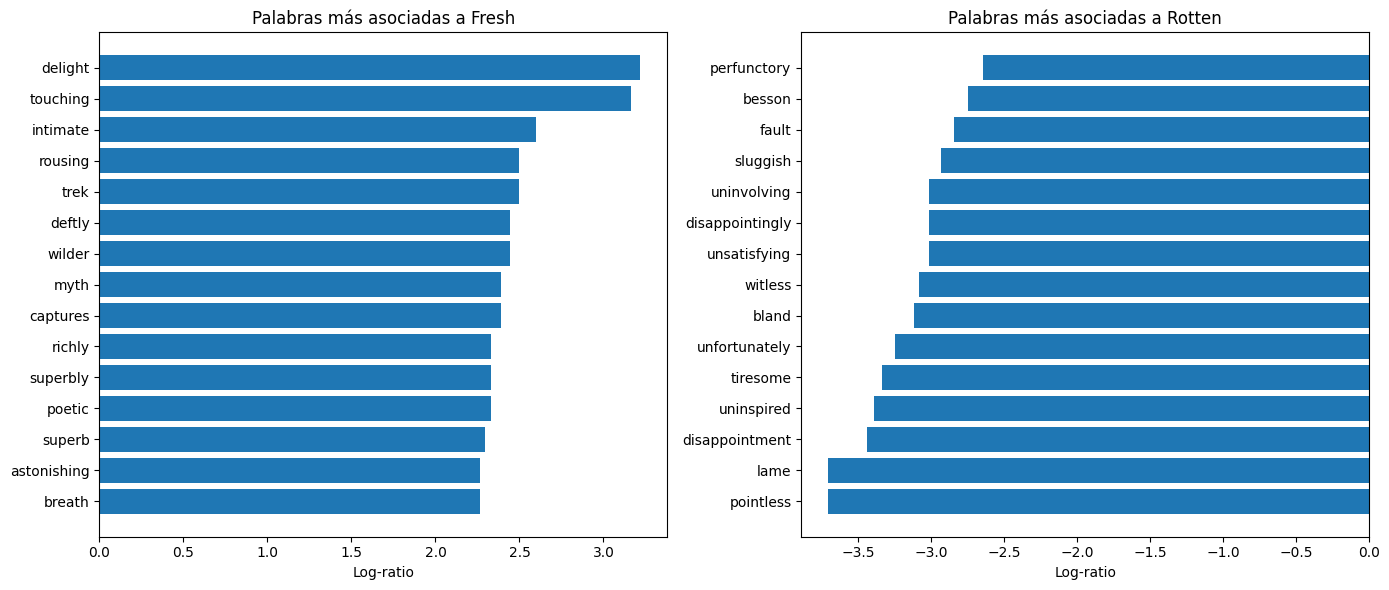

In [67]:
# TODO: Visualizar las palabras más predictivas
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, grafique las palabras más positivas con barh()
# 3. En el segundo subplot, grafique las palabras más negativas
# 4. Agregue títulos y etiquetas

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names[top_positive], log_ratio[top_positive])
axes[0].set_title("Palabras más asociadas a Fresh")
axes[0].set_xlabel("Log-ratio")

axes[1].barh(feature_names[top_negative], log_ratio[top_negative])
axes[1].set_title("Palabras más asociadas a Rotten")
axes[1].set_xlabel("Log-ratio")

plt.tight_layout()
plt.show()

### Pregunta 9: Interpretabilidad
¿Qué tipo de palabras esperaría encontrar asociadas a reseñas negativas?

A) Palabras como "excellent", "amazing", "brilliant"  
B) Palabras como "boring", "bad", "disappointing"  
C) Palabras neutrales como "the", "and", "is"  
D) Nombres de actores  

**Su Respuesta:** B

## Parte 10: Predicción con Nuevas Reseñas

In [68]:
# TODO: Probar el modelo con nuevas reseñas
#
# Instrucciones:
# 1. Defina una lista de nuevas reseñas de ejemplo
# 2. Transforme con vectorizer.transform(new_reviews)
# 3. Prediga con clf_nb.predict()
# 4. Obtenga probabilidades con clf_nb.predict_proba()
# 5. Imprima cada reseña con su predicción y probabilidades

new_reviews = [
    "This movie is absolutely amazing! Best film of the year!",
    "Terrible waste of time. Boring and predictable.",
    "A decent film with good performances but weak plot.",
    "Masterpiece! Incredible acting and stunning visuals.",
    "I've seen better. Nothing special about this one."
]

# Transformamos las nuevas reseñas con el mismo vectorizador
new_X = vectorizer.transform(new_reviews)

# Predicción de clase
new_pred = clf_nb.predict(new_X)

# Probabilidades por clase
new_prob = clf_nb.predict_proba(new_X)

for review, pred, prob in zip(new_reviews, new_pred, new_prob):
    etiqueta = "fresh" if pred == 1 else "rotten"
    print(f"Reseña: {review}")
    print(f"Predicción: {etiqueta}")
    print(f"Probabilidades -> rotten: {prob[0]:.4f}, fresh: {prob[1]:.4f}")
    print("-" * 80)

Reseña: This movie is absolutely amazing! Best film of the year!
Predicción: fresh
Probabilidades -> rotten: 0.0146, fresh: 0.9854
--------------------------------------------------------------------------------
Reseña: Terrible waste of time. Boring and predictable.
Predicción: rotten
Probabilidades -> rotten: 0.9901, fresh: 0.0099
--------------------------------------------------------------------------------
Reseña: A decent film with good performances but weak plot.
Predicción: rotten
Probabilidades -> rotten: 0.5154, fresh: 0.4846
--------------------------------------------------------------------------------
Reseña: Masterpiece! Incredible acting and stunning visuals.
Predicción: fresh
Probabilidades -> rotten: 0.0071, fresh: 0.9929
--------------------------------------------------------------------------------
Reseña: I've seen better. Nothing special about this one.
Predicción: rotten
Probabilidades -> rotten: 0.6771, fresh: 0.3229
-------------------------------------------

### Pregunta 10: Predicciones
¿Qué método se usa para obtener las probabilidades de cada clase?

A) predict()  
B) predict_proba()  
C) score()  
D) fit()  

**Su Respuesta:** B

## Parte 11: Comparación de Modelos

,Modelo,Train Accuracy,Test Accuracy,Precision,Recall,F1
0,Multinomial NB,0.864159,0.770221,0.806708,0.820035,0.813317
1,Bernoulli NB,0.866090,0.769792,0.805728,0.820738,0.813164
2,Multinomial + TF-IDF,0.844661,0.748552,0.733855,0.922671,0.817502


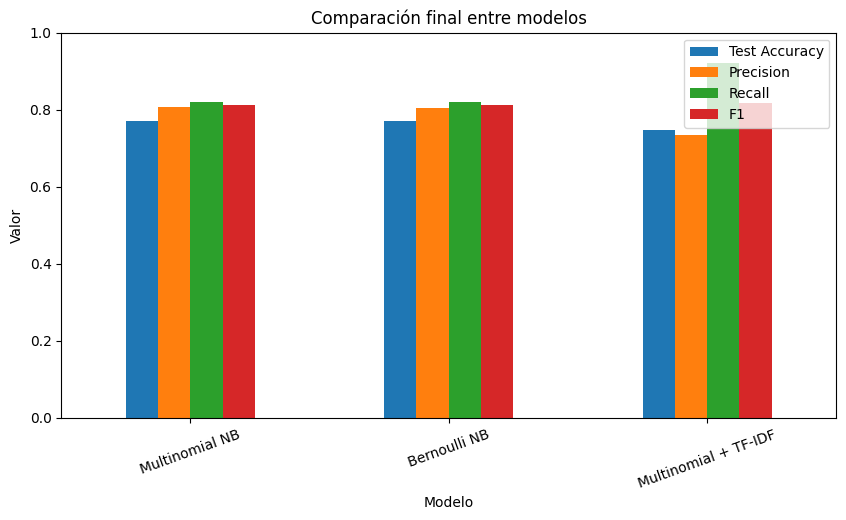

In [69]:
# TODO: Comparar Multinomial vs Bernoulli Naive Bayes
#
# Instrucciones:
# 1. Cree y entrene BernoulliNB() con los mismos datos
# 2. Calcule precisiones train/test
# 3. Cree un DataFrame comparando:
#    - Multinomial NB
#    - Bernoulli NB
#    - Multinomial + TF-IDF
# 4. Imprima la tabla comparativa

# Para Bernoulli usamos una representación binaria
vectorizer_bin = CountVectorizer(min_df=5, binary=True)
X_bin, y_bin = make_xy(critics, vectorizer_bin)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin,
    test_size=0.3,
    random_state=22,
    stratify=y_bin
)

clf_bern = BernoulliNB()
clf_bern.fit(X_train_bin, y_train_bin)

pred_train_bern = clf_bern.predict(X_train_bin)
pred_test_bern = clf_bern.predict(X_test_bin)

comparacion_modelos = pd.DataFrame({
    "Modelo": ["Multinomial NB", "Bernoulli NB", "Multinomial + TF-IDF"],
    "Train Accuracy": [
        accuracy_score(y_train, y_pred_train),
        accuracy_score(y_train_bin, pred_train_bern),
        accuracy_score(y_train_tfidf, pred_train_tfidf)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_test),
        accuracy_score(y_test_bin, pred_test_bern),
        accuracy_score(y_test_tfidf, pred_test_tfidf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_test),
        precision_score(y_test_bin, pred_test_bern),
        precision_score(y_test_tfidf, pred_test_tfidf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_test),
        recall_score(y_test_bin, pred_test_bern),
        recall_score(y_test_tfidf, pred_test_tfidf)
    ],
    "F1": [
        f1_score(y_test, y_pred_test),
        f1_score(y_test_bin, pred_test_bern),
        f1_score(y_test_tfidf, pred_test_tfidf)
    ]
})

display(comparacion_modelos)

# Imprimir comparación de modelos
comparacion_graf = comparacion_modelos.set_index("Modelo")[["Test Accuracy", "Precision", "Recall", "F1"]]

comparacion_graf.plot(kind="bar", figsize=(10, 5))
plt.title("Comparación final entre modelos")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()


### Pregunta 11: Multinomial vs Bernoulli
¿Cuál es la diferencia principal entre Multinomial y Bernoulli Naive Bayes?

A) No hay diferencia  
B) Multinomial usa conteos de palabras, Bernoulli usa presencia/ausencia binaria  
C) Bernoulli es siempre mejor  
D) Multinomial solo funciona con TF-IDF  

**Su Respuesta:** B

### Pregunta 12: Suposición de Naive Bayes
¿Cuál es la suposición principal del algoritmo Naive Bayes?

A) Las características tienen distribución normal  
B) Las características son independientes dada la clase  
C) Los datos deben estar normalizados  
D) Debe haber balance de clases  

**Su Respuesta:** B

### Pregunta 13: Ventajas de Naive Bayes
¿Cuál es una ventaja de Naive Bayes para clasificación de texto?

A) Siempre da la mejor precisión  
B) Es rápido de entrenar y funciona bien con alta dimensionalidad  
C) No requiere preprocesamiento  
D) Captura relaciones complejas entre palabras  

**Su Respuesta:** B

### Pregunta 14: Stop Words
¿Qué son las "stop words" en procesamiento de texto?

A) Palabras con errores ortográficos  
B) Palabras muy comunes que aportan poca información (the, is, and)  
C) Palabras negativas  
D) Palabras técnicas  

**Su Respuesta:** B

### Pregunta 15: min_df en CountVectorizer
¿Qué hace el parámetro min_df=5 en CountVectorizer?

A) Limita a 5 palabras por documento  
B) Ignora palabras que aparecen en menos de 5 documentos  
C) Usa solo las 5 palabras más frecuentes  
D) Divide los datos en 5 partes  

**Su Respuesta:** B

## ¡Excelente Trabajo!

Responda las preguntas basadas en sus ejecuciones. Entregue el notebook completado con todas las celdas ejecutadas.